In [21]:
import xarray as xr
import numpy as np
import xesmf as xe #this package is very unestable, if error try restart krenel
import matplotlib.pyplot as plt
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
import imageio
import io

In [22]:
GFW_ds = xr.open_zarr(
    "./data/processed/GFW_AIS.zarr",
    decode_timedelta=True
)

In [23]:
GFW_ds

<xarray.Dataset> Size: 2GB
Dimensions:   (flag: 27, geartype: 2, time: 156, lat: 222, lon: 158)
Coordinates:
  * flag      (flag) object 216B 'ALB' 'ARE' 'ARG' 'BLZ' ... 'UKR' 'URY' 'VUT'
  * geartype  (geartype) object 16B 'SQUID_JIGGER' 'TRAWLERS'
  * lat       (lat) float64 2kB -60.0 -59.88 -59.75 ... -32.62 -32.5 -32.38
  * lon       (lon) float64 1kB -69.61 -69.48 -69.36 ... -50.23 -50.11 -49.98
  * time      (time) datetime64[ns] 1kB 2012-01-01 2012-02-01 ... 2024-12-01
Data variables:
    hours     (time, flag, geartype, lat, lon) float64 2GB dask.array<chunksize=(20, 7, 1, 56, 40), meta=np.ndarray>
Attributes:
    created_by:     Ruben Barriuso
    description:    Monthly fishing hours per grid cell in the SW Atlantic, \...
    regrid_method:  conservative
    resolution:     0.125x0.125 degree
    source:         Global Fishing Watch (GFW)
    title:          Regrided SW Atlantic GFW AIS Fishing Effort Data (2012-2024)

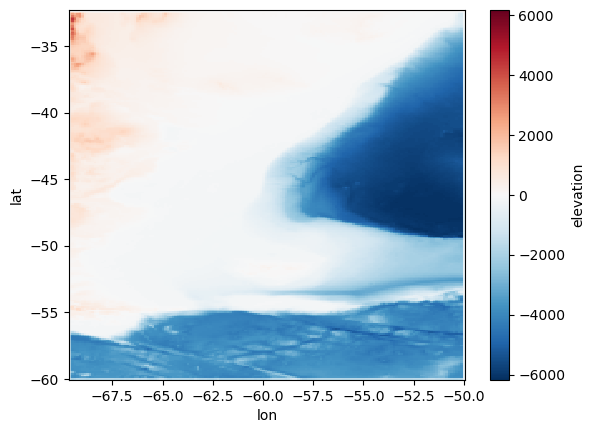

In [24]:
bat_ds = xr.open_zarr(
    "./resources/GEBCO/GEBCO_regridded.zarr",
    decode_timedelta=True
)
bat_ds["elevation"].plot()


In [25]:
eez_path = "./resources/Marine_Regions/World_EEZ_v12/eez_v12.shp"
min_lon, min_lat, max_lon, max_lat = [-69.61, -60., -50., -32.45] #SW Atlantic bbox (roundeed to the second decimal)
bbox = [min_lon, min_lat, max_lon, max_lat]
eez_gdf = gpd.read_file(eez_path, bbox=tuple(bbox))

In [26]:
def plot_fishing(month,flag):
    fig = plt.figure(figsize=(12, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())

    ax.set_extent([
        bbox[0] + 2, # Left
        bbox[2] - 2, # Right
        bbox[1] + 3, # Bottom
        bbox[3] - 5  # Top
    ], crs=ccrs.PlateCarree())


    fishing_data = GFW_ds["hours"].sel(flag=flag, time=month).sum(dim=["geartype"]).compute()
    fishing_data = fishing_data.where(fishing_data > 10)

    fishing_data.plot(ax=ax, transform=ccrs.PlateCarree(),
                        vmin=0, vmax=100,
                        cmap='viridis',
                        add_colorbar=True, cbar_kwargs={'label': 'Horas de pesca de AIS', 'extend': 'max'},
                        zorder=2)

    bat_ds["elevation"].plot(ax=ax, transform=ccrs.PlateCarree(), 
                            vmin=-2000, vmax=0,
                            cmap = "grey",
                            alpha=0.8, 
                            add_colorbar=True, cbar_kwargs={'label': 'Depth (m)'},
                            zorder=1)


    ax.add_feature(cfeature.LAND, facecolor='gray', edgecolor='gray', zorder=3)
    ax.add_geometries(eez_gdf.geometry, crs=ccrs.PlateCarree(), edgecolor='grey', facecolor='none')
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, zorder=4)

    plt.title(f"{flag} {month}", fontsize=14, fontweight='bold', pad=20)

    return fig

In [27]:
#España
months = pd.date_range(start="2012-01", end="2024-12", freq="MS").strftime("%Y-%m").tolist()
flag = "ESP"

frames = []

for month_str in months:
    print(f"Processing: {month_str}") # To track progress
    
    # Generate the plot using your existing logic
    fig = plot_fishing(month_str, flag) 
    
    # Convert plot to image frame
    buf = io.BytesIO()
    plt.savefig(buf, format='png', dpi=100, bbox_inches='tight')
    plt.close(fig)
    buf.seek(0)
    frames.append(imageio.v2.imread(buf))

# Save the final animation
imageio.mimsave(f'./data/gifs/fishing_activity_{flag}.gif', frames, fps=1)

Processing: 2012-01
Processing: 2012-02
Processing: 2012-03
Processing: 2012-04
Processing: 2012-05
Processing: 2012-06
Processing: 2012-07
Processing: 2012-08
Processing: 2012-09
Processing: 2012-10
Processing: 2012-11
Processing: 2012-12
Processing: 2013-01
Processing: 2013-02
Processing: 2013-03
Processing: 2013-04
Processing: 2013-05
Processing: 2013-06
Processing: 2013-07
Processing: 2013-08
Processing: 2013-09
Processing: 2013-10
Processing: 2013-11
Processing: 2013-12
Processing: 2014-01
Processing: 2014-02
Processing: 2014-03
Processing: 2014-04
Processing: 2014-05
Processing: 2014-06
Processing: 2014-07
Processing: 2014-08
Processing: 2014-09
Processing: 2014-10
Processing: 2014-11
Processing: 2014-12
Processing: 2015-01
Processing: 2015-02
Processing: 2015-03
Processing: 2015-04
Processing: 2015-05
Processing: 2015-06
Processing: 2015-07
Processing: 2015-08
Processing: 2015-09
Processing: 2015-10
Processing: 2015-11
Processing: 2015-12
Processing: 2016-01
Processing: 2016-02


In [28]:
#Taiwan
months = pd.date_range(start="2012-01", end="2024-12", freq="MS").strftime("%Y-%m").tolist()
flag = "TWN"

frames = []

for month_str in months:
    print(f"Processing: {month_str}") # To track progress
    
    # Generate the plot using your existing logic
    fig = plot_fishing(month_str, flag) 
    
    # Convert plot to image frame
    buf = io.BytesIO()
    plt.savefig(buf, format='png', dpi=100, bbox_inches='tight')
    plt.close(fig)
    buf.seek(0)
    frames.append(imageio.v2.imread(buf))

# Save the final animation
imageio.mimsave(f'./data/gifs/fishing_activity_{flag}.gif', frames, fps=1)

Processing: 2012-01
Processing: 2012-02
Processing: 2012-03
Processing: 2012-04
Processing: 2012-05
Processing: 2012-06
Processing: 2012-07
Processing: 2012-08
Processing: 2012-09
Processing: 2012-10
Processing: 2012-11
Processing: 2012-12
Processing: 2013-01
Processing: 2013-02
Processing: 2013-03
Processing: 2013-04
Processing: 2013-05
Processing: 2013-06
Processing: 2013-07
Processing: 2013-08
Processing: 2013-09
Processing: 2013-10
Processing: 2013-11
Processing: 2013-12
Processing: 2014-01
Processing: 2014-02
Processing: 2014-03
Processing: 2014-04
Processing: 2014-05
Processing: 2014-06
Processing: 2014-07
Processing: 2014-08
Processing: 2014-09
Processing: 2014-10
Processing: 2014-11
Processing: 2014-12
Processing: 2015-01
Processing: 2015-02
Processing: 2015-03
Processing: 2015-04
Processing: 2015-05
Processing: 2015-06
Processing: 2015-07
Processing: 2015-08
Processing: 2015-09
Processing: 2015-10
Processing: 2015-11
Processing: 2015-12
Processing: 2016-01
Processing: 2016-02


In [29]:
#Falklands
months = pd.date_range(start="2012-01", end="2024-12", freq="MS").strftime("%Y-%m").tolist()
flag = "FLK"

frames = []

for month_str in months:
    print(f"Processing: {month_str}") # To track progress
    
    # Generate the plot using your existing logic
    fig = plot_fishing(month_str, flag) 
    
    # Convert plot to image frame
    buf = io.BytesIO()
    plt.savefig(buf, format='png', dpi=100, bbox_inches='tight')
    plt.close(fig)
    buf.seek(0)
    frames.append(imageio.v2.imread(buf))

# Save the final animation
imageio.mimsave(f'./data/gifs/fishing_activity_{flag}.gif', frames, fps=1)

Processing: 2012-01
Processing: 2012-02
Processing: 2012-03
Processing: 2012-04
Processing: 2012-05
Processing: 2012-06
Processing: 2012-07
Processing: 2012-08
Processing: 2012-09
Processing: 2012-10
Processing: 2012-11
Processing: 2012-12
Processing: 2013-01
Processing: 2013-02
Processing: 2013-03
Processing: 2013-04
Processing: 2013-05
Processing: 2013-06
Processing: 2013-07
Processing: 2013-08
Processing: 2013-09
Processing: 2013-10
Processing: 2013-11
Processing: 2013-12
Processing: 2014-01
Processing: 2014-02
Processing: 2014-03
Processing: 2014-04
Processing: 2014-05
Processing: 2014-06
Processing: 2014-07
Processing: 2014-08
Processing: 2014-09
Processing: 2014-10
Processing: 2014-11
Processing: 2014-12
Processing: 2015-01
Processing: 2015-02
Processing: 2015-03
Processing: 2015-04
Processing: 2015-05
Processing: 2015-06
Processing: 2015-07
Processing: 2015-08
Processing: 2015-09
Processing: 2015-10
Processing: 2015-11
Processing: 2015-12
Processing: 2016-01
Processing: 2016-02


In [30]:
#China
months = pd.date_range(start="2012-01", end="2024-12", freq="MS").strftime("%Y-%m").tolist()
flag = "CHN"

frames = []

for month_str in months:
    print(f"Processing: {month_str}") # To track progress
    
    # Generate the plot using your existing logic
    fig = plot_fishing(month_str, flag) 
    
    # Convert plot to image frame
    buf = io.BytesIO()
    plt.savefig(buf, format='png', dpi=100, bbox_inches='tight')
    plt.close(fig)
    buf.seek(0)
    frames.append(imageio.v2.imread(buf))

# Save the final animation
imageio.mimsave(f'./data/gifs/fishing_activity_{flag}.gif', frames, fps=1)

Processing: 2012-01
Processing: 2012-02
Processing: 2012-03
Processing: 2012-04
Processing: 2012-05
Processing: 2012-06
Processing: 2012-07
Processing: 2012-08
Processing: 2012-09
Processing: 2012-10
Processing: 2012-11
Processing: 2012-12
Processing: 2013-01
Processing: 2013-02
Processing: 2013-03
Processing: 2013-04
Processing: 2013-05
Processing: 2013-06
Processing: 2013-07
Processing: 2013-08
Processing: 2013-09
Processing: 2013-10
Processing: 2013-11
Processing: 2013-12
Processing: 2014-01
Processing: 2014-02
Processing: 2014-03
Processing: 2014-04
Processing: 2014-05
Processing: 2014-06
Processing: 2014-07
Processing: 2014-08
Processing: 2014-09
Processing: 2014-10
Processing: 2014-11
Processing: 2014-12
Processing: 2015-01
Processing: 2015-02
Processing: 2015-03
Processing: 2015-04
Processing: 2015-05
Processing: 2015-06
Processing: 2015-07
Processing: 2015-08
Processing: 2015-09
Processing: 2015-10
Processing: 2015-11
Processing: 2015-12
Processing: 2016-01
Processing: 2016-02
